# Diabetes

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore') # Gereksiz uyarıları gizler

In [21]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

*   **Pregnancies (Hamilelik Sayısı):** Kişinin bugüne kadar kaç kez hamile kaldığını ifade eder.
*   **Glucose (Glikoz):** Oral glikoz tolerans testinde 2 saatlik plazma glikoz konsantrasyonudur (kan şekeri değeri).
*   **BloodPressure (Kan Basıncı):** Diyastolik kan basıncıdır (halk arasında bilinen adıyla "küçük tansiyon", mm Hg cinsinden ölçülür).
*   **SkinThickness (Cilt Kalınlığı):** Triceps (arka kol) cilt kıvrım kalınlığıdır (mm cinsinden). Genellikle vücut yağ oranını tahmin etmek için kullanılan bir ölçümdür.
*   **Insulin (İnsülin):** 2 saatlik serum insülin değeridir (mu U/ml).
*   **BMI (Vücut Kitle İndeksi):** Kişinin vücut kitle indeksidir. Ağırlığın boyun karesine bölünmesiyle hesaplanır (Ağırlık (kg) / Boy ($m^2$)).
*   **DiabetesPedigreeFunction (Diyabet Soyağacı Fonksiyonu):** Kişinin aile geçmişindeki diyabet vakalarına dayanarak genetik olarak diyabet olma olasılığını skorlayan bir fonksiyondur.
*   **Age (Yaş):** Kişinin yaşını (yıl olarak) belirtir.

**Hedef Değişken**

*   **Outcome (Sonuç):** Sınıflandırma algoritmalarında modelin tahmin etmeye çalışacağı hedef (target) değişkendir. **1** değeri kişinin diyabetli olduğunu, **0** değeri ise diyabetli olmadığını gösterir.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Veri setinde boş değer yok tüm veriler sayısal formatta.

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### İstatistiksel Özet ve Anomali Analizi

**1. Biyolojik Olarak İmkansız Değerler (Gizli Eksik Veriler):**
Tablodaki `min` (minimum) değerleri incelendiğinde, bazı biyolojik ölçümlerin **0** olduğu görülmektedir. Bu durum fizyolojik olarak imkansızdır ve bu sıfırların aslında eksik veri (NaN) olarak sisteme girildiğini gösterir. İlgili ön işleme adımlarında bu sıfırların tedavi edilmesi gerekir. Bu sütunlar şunlardır:
*   `Glucose` (Glikoz)
*   `BloodPressure` (Kan Basıncı)
*   `SkinThickness` (Cilt Kalınlığı)
*   `Insulin` (İnsülin)
*   `BMI` (Vücut Kitle İndeksi)

**2. Kritik Aykırı Değerler (Outliers) ve Çarpıklık:**
Maksimum (`max`) ve 3. Çeyreklik (`75%`) değerleri karşılaştırıldığında sağa çarpık (right-skewed) dağılım sergileyen ve modele zarar verebilecek uç değerler barındıran özellikler şunlardır:
*   **`Insulin`:** Verilerin %75'i 127.25'in altındayken, maksimum değer **846**'dır. Çok ciddi bir sağa çarpıklık ve ekstrem aykırı değerler barındırmaktadır.
*   **`Pregnancies`:** Verilerin %75'i 6 ve altındayken, maksimum değer **17**'dir. Biyolojik olarak mümkün olsa da veri seti içinde istatistiksel bir aykırı değerdir.
*   **`SkinThickness`:** Maksimum değer olan **99**, ortalama (20.5) ve medyan (23) değerlerine göre oldukça yüksektir.
*   **`DiabetesPedigreeFunction`:** 3. çeyreklik 0.626 iken maksimum değer **2.42**'dir. Üst bantta aykırı değerler mevcuttur.

**3. Veri Dağılımı ve Sınıf Dengesizliği:**
*   `Outcome` (Hedef Değişken) sütununun ortalaması (`mean`) **0.348**'dir. Bu da veri setindeki gözlemlerin yalnızca yaklaşık %34.8'inin pozitif sınıf (diyabetli), geri kalanının negatif sınıf olduğunu gösterir. Modelleme aşamasında hafif bir sınıf dengesizliği (class imbalance) problemi dikkate alınmalıdır.

In [14]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### Modelleme Stratejisi: Sınıf Dengesizliği (Class Imbalance) ve Veri Sızıntısı (Data Leakage) Önlemleri

Hedef değişkenimiz olan `Outcome` sınıfında ~%65 (Negatif) ve ~%35 (Pozitif) şeklinde bir dengesizlik bulunmaktadır. Modelin çoğunluk sınıfına aşırı uyum (overfitting) sağlamasını engellemek için aşağıdaki strateji izlenecektir:

1. **Veri Sızıntısını Önleme:** Test setinin gerçek dünya dağılımını koruması ve modelin görmediği verilerle test edilmesi için, sınıf dengeleme işlemleri **kesinlikle Train/Test ayrımı yapıldıktan sonra**, yalnızca eğitim (`X_train`, `y_train`) seti üzerinde uygulanacaktır.
2. **Dengeleme Yöntemi:** Veri setimiz küçük hacimli olduğu için veri kaybı yaratacak Undersampling yöntemleri yerine;
   * Ağaç tabanlı modellerde `class_weight='balanced'` (XGBoost için `scale_pos_weight`) parametreleri ile maliyet duyarlı öğrenme (Cost-sensitive learning) tercih edilecektir.
   * Gerekli görülürse eğitim seti üzerinde **SMOTE** (Synthetic Minority Over-sampling Technique) uygulanarak sentetik veri artırımı yapılacaktır.
3. **Değerlendirme Metrikleri:** Model performansı yanıltıcı olabilen *Accuracy* yerine; *Recall*, *Precision*, *F1-Score* ve *ROC-AUC* metrikleri üzerinden değerlendirilecektir.

In [ ]:
# Tüm değişkenleri tek bir görselde alt formatlarda (subplot) görebilmek için 
# veriyi 'Outcome' sabit kalacak şekilde eritiyoruz (melt).
df_melted = df.melt(id_vars='Outcome', var_name='Ozellik', value_name='Deger')

# Plotly'nin sınıfları ayrık (discrete) renklerle göstermesi için Outcome'ı string (kategorik) yapıyoruz.
df_melted['Outcome'] = df_melted['Outcome'].astype(str)

# Plotly Express ile Boxplot çizimi
fig = px.box(
    df_melted,
    x='Outcome',
    y='Deger',
    facet_col='Ozellik',
    facet_col_wrap=3,        # Grafikleri yan yana 3 sütun olacak şekilde dizer
    color='Outcome',         # Diyabet durumuna (0 ve 1) göre renklendirir
    title='Hedef Değişkene (Outcome) Göre Tüm Özelliklerin Bağlamsal Aykırı Değer Analizi',
    template='plotly_white'  # Daha temiz bir arka plan görünümü için
)

# En önemli adım: Her özelliğin kendi değer aralığı farklı olduğu için 
# (örneğin BMI 20-50 arası, Insulin 0-800 arası) Y eksenlerini serbest bırakıyoruz.
fig.update_yaxes(matches=None)

# Eksen başlıklarını temizlemek ve grafiği büyütmek için küçük dokunuşlar
fig.for_each_yaxis(lambda yaxis: yaxis.update(title=''))
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_layout(height=900, showlegend=False) # Renkler zaten Outcome'ı gösterdiği için lejantı gizleyebiliriz

fig.show()

### Keşifçi Veri Analizi (EDA) ve Ön İşleme Kararları Özeti

Yapılan istatistiksel (describe) ve bağlamsal (boxplot) analizler sonucunda veri setiyle ilgili alınan ön işleme kararları şunlardır:

**1. Özelliklerin Hedef Değişkene Etkisi:**
* **Güçlü Etki:** `Glucose`, `BMI`, `Age` ve `Pregnancies` değişkenleri diyabet (Outcome) sınıflarını ayırmada yüksek ayırt ediciliğe sahiptir.
* **Zayıf/Etkisiz:** `BloodPressure` değişkeninin iki sınıf arasında belirgin bir ayrım yaratmadığı gözlemlenmiştir.

**2. Biyolojik Anormallikler (Gizli Eksik Veriler):**
* `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` ve `BMI` sütunlarındaki minimum `0` değerleri biyolojik olarak imkansız olduğundan **eksik veri (NaN)** olarak kabul edilecektir. 
* *Müdahale:* Bu değerler, veri sızıntısını önlemek adına veri bölünmesi yapıldıktan sonra, ait oldukları hedef sınıfın (Outcome 0 veya 1) **medyan değerleri** (veya KNN Imputer) ile doldurulacaktır.

**3. İstatistiksel Aykırı Değerler (Outliers) ve Çarpıklık:**
* Özellikle `Insulin`, `Pregnancies` ve `DiabetesPedigreeFunction` değişkenlerinde aşırı sağa çarpıklık (right-skewness) ve üst bant aykırı değerleri tespit edilmiştir (Örn: Max İnsülin = 846).
* *Müdahale:* Ağaç tabanlı algoritmalar kullanılacaksa bu değerler doğal haliyle bırakılacak; lineer veya uzaklık tabanlı algoritmalar denenecekse üst çeyreklik sınırlarından **Baskılama (Winsorization)** veya **Logaritmik Dönüşüm** uygulanacaktır.

In [15]:
# 1. Biyolojik olarak 0 olması imkansız olan sütunların listesini oluşturalım
eksik_olabilecek_sutunlar = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Değişiklik yapmadan önce bu sütunlarda kaç tane 0 olduğunu görelim
print("--- 0 Olarak Girilmiş (Gizli) Eksik Veri Sayıları ---")
for sutun in eksik_olabilecek_sutunlar:
    sifir_sayisi = (df[sutun] == 0).sum()
    print(f"{sutun}: {sifir_sayisi} adet")

print("\n")

# 3. Bu sütunlardaki 0 değerlerini NumPy'ın NaN (Not a Number) değeri ile değiştirelim
df[eksik_olabilecek_sutunlar] = df[eksik_olabilecek_sutunlar].replace(0, np.nan)

# 4. İşlemin başarılı olup olmadığını kontrol edelim (Artık 0 yerine NaN sayısını göreceğiz)
print("--- NaN'a Dönüştürüldükten Sonra Gerçek Eksik Veri Sayıları ---")
print(df[eksik_olabilecek_sutunlar].isnull().sum())

--- 0 Olarak Girilmiş (Gizli) Eksik Veri Sayıları ---
Glucose: 5 adet
BloodPressure: 35 adet
SkinThickness: 227 adet
Insulin: 374 adet
BMI: 11 adet


--- NaN'a Dönüştürüldükten Sonra Gerçek Eksik Veri Sayıları ---
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [16]:
# Eksik verileri yüzde olarak yazdır
eksik_yuzdeleri = df.isnull().mean() * 100

print("--- Eksik Veri Yüzdeleri (%) ---")
print(eksik_yuzdeleri[eksik_yuzdeleri > 0].sort_values(ascending=False).round(2))

--- Eksik Veri Yüzdeleri (%) ---
Insulin          48.70
SkinThickness    29.56
BloodPressure     4.56
BMI               1.43
Glucose           0.65
dtype: float64


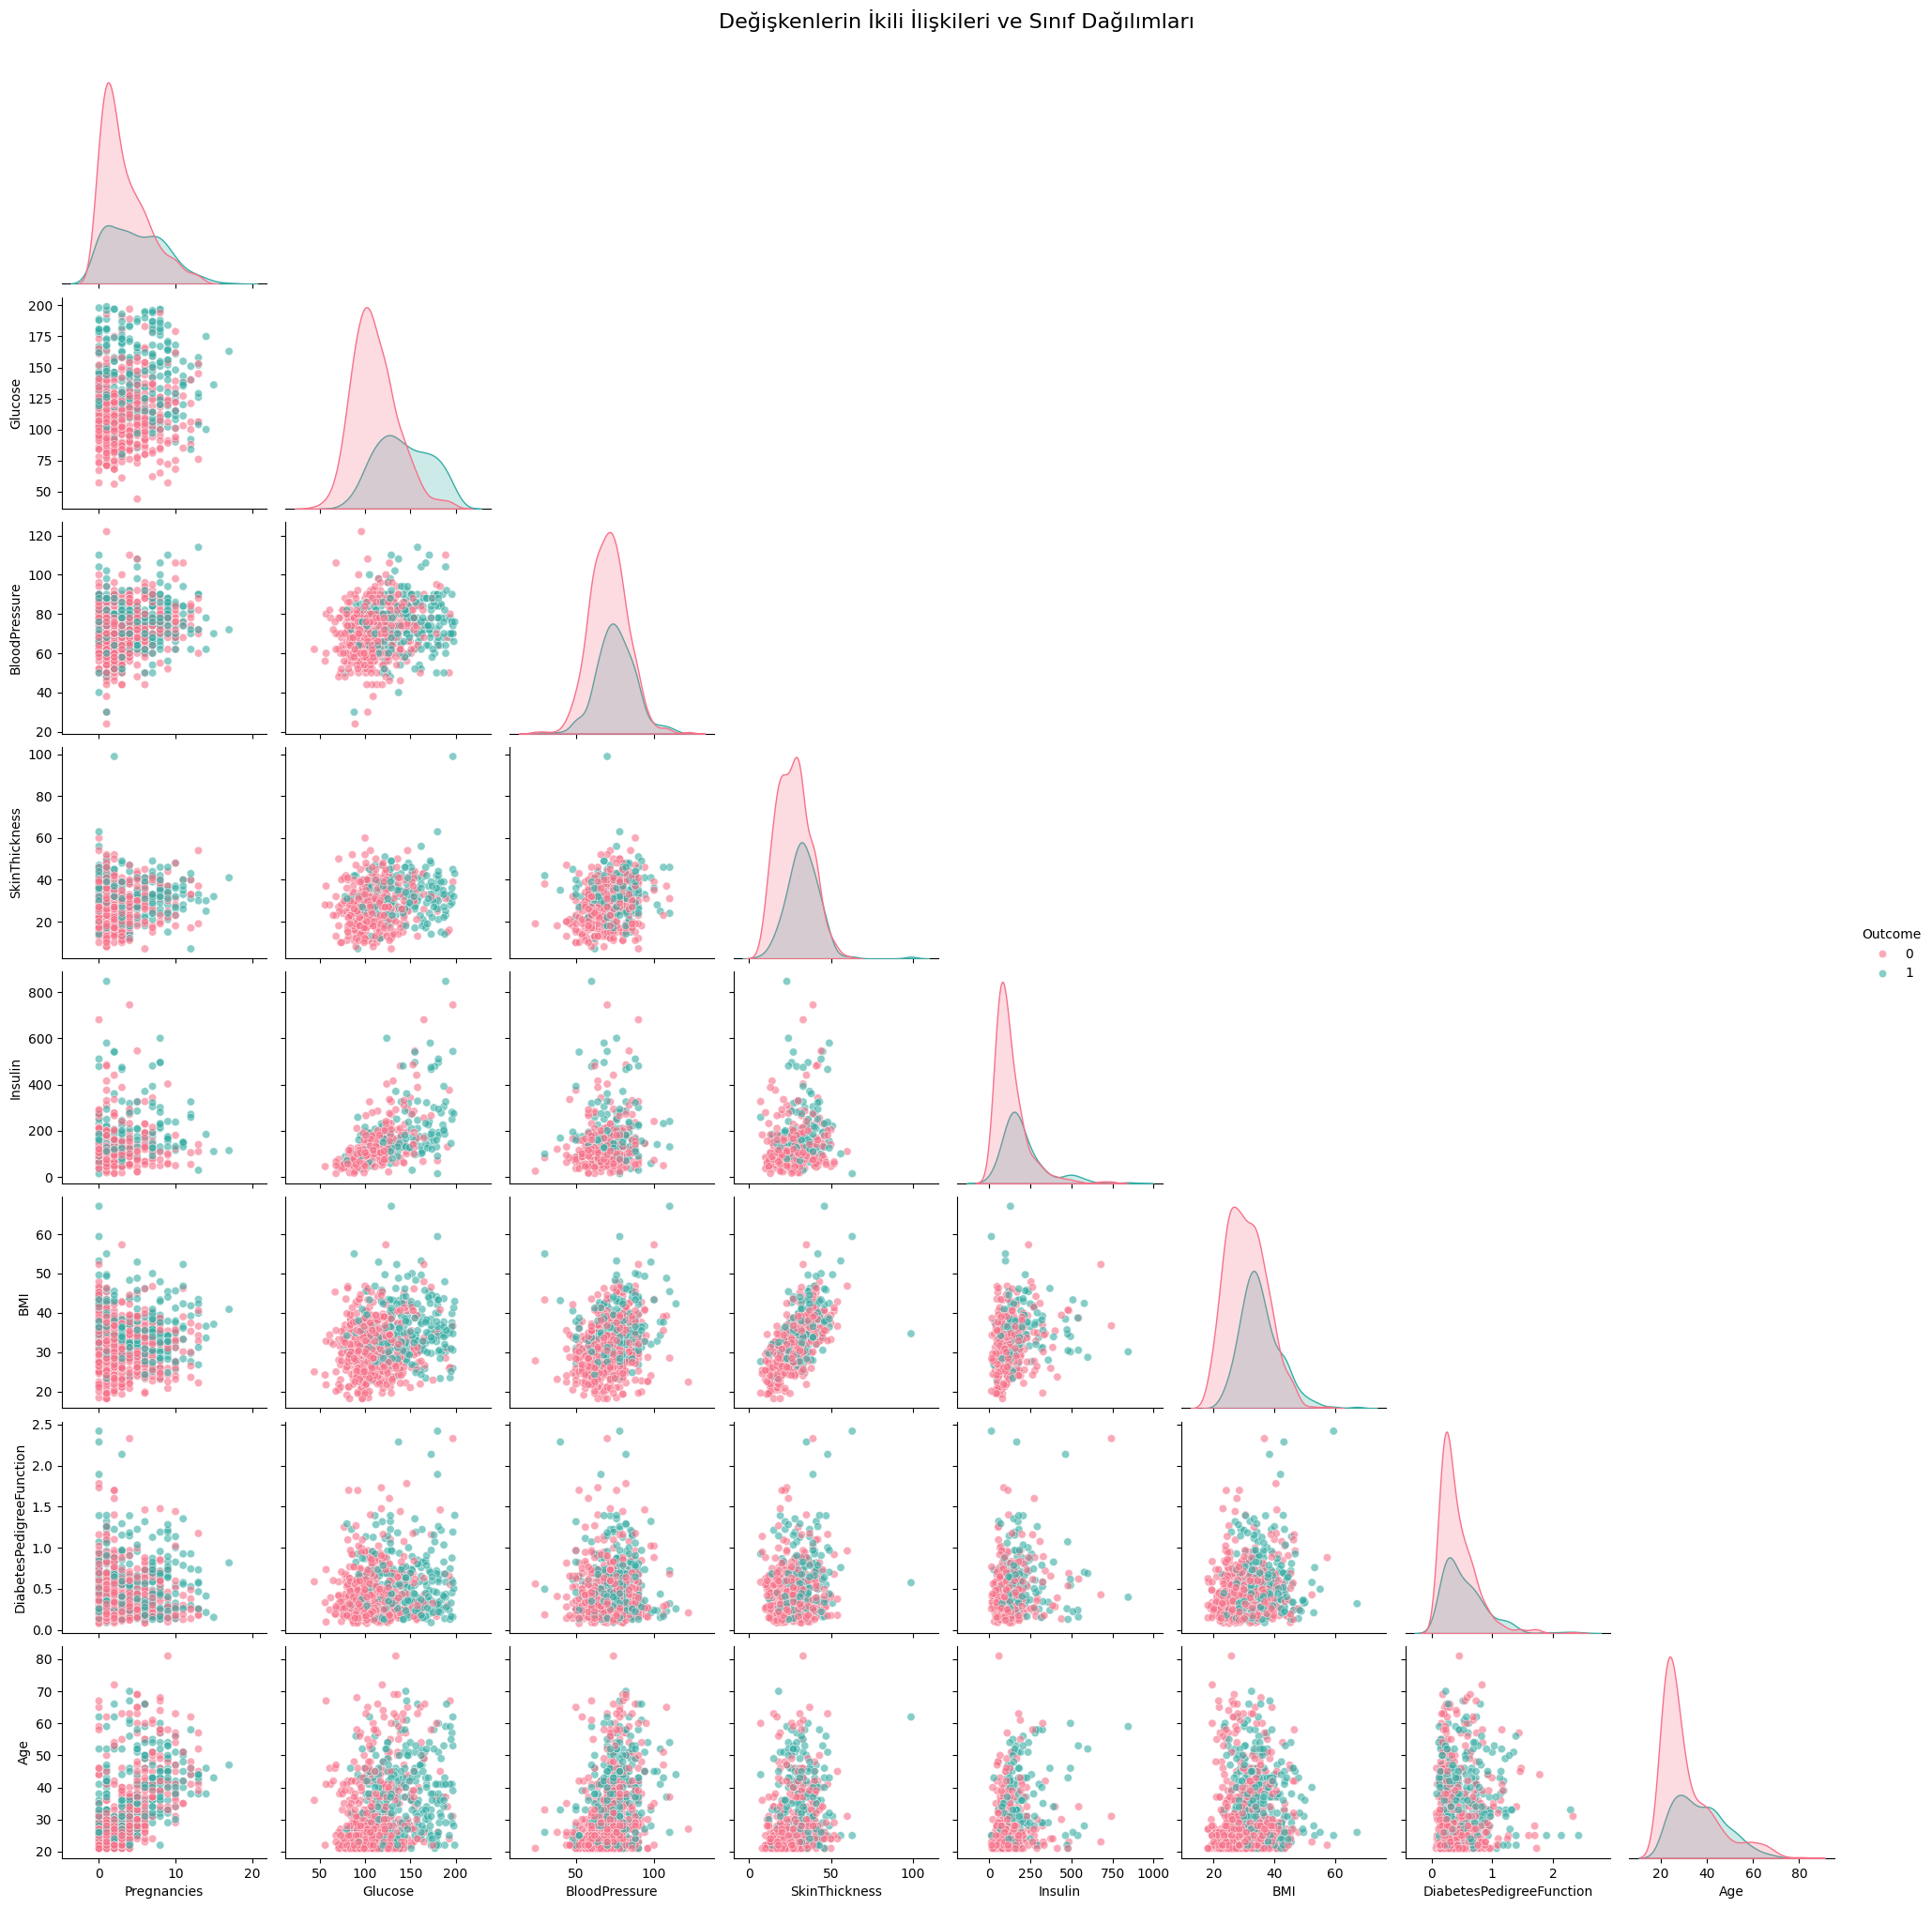

In [17]:
# Hedef değişkene göre renklendirilmiş çoklu dağılım grafiği
# corner=True parametresi ile gereksiz üst üçgeni kaldırıp grafiği sadeleştiriyoruz
g = sns.pairplot(df, 
                 hue='Outcome',      # Sınıfları farklı renklerde gösterir
                 corner=True,        # Sadece alt üçgeni çizer
                 palette='husl',     # Okunması kolay bir renk paleti
                 plot_kws={'alpha': 0.6}, # Noktaların saydamlığını ayarlar (üst üste binenleri görmek için)
                 diag_kind='kde')    # Köşegenlerde yoğunluk (KDE) grafiği gösterir

# Ana başlığı yukarıya, grafikle çakışmayacak şekilde ekliyoruz
g.fig.suptitle('Değişkenlerin İkili İlişkileri ve Sınıf Dağılımları', y=1.02, fontsize=16)

plt.show()

### Çoklu Dağılım ve İlişki Analizi (Pairplot) Özeti

Değişkenlerin birbirleriyle olan ikili etkileşimlerini ve hedef sınıflara (Diyabetli / Sağlıklı) göre dağılımlarını incelediğimizde şu temel sonuçlara ulaşılmıştır:

**1. Tekil Ayırt Edicilik (Köşegen - KDE Dağılımları):**
*   **En Güçlü Belirteç (Glucose):** İki sınıfın (pembe ve yeşil) tepe noktalarının birbirinden en net ayrıştığı değişken glikozdur. Diyabetli grubun glikoz dağılımı bariz bir şekilde sağa (yüksek değerlere) kaymıştır.
*   **İkincil Belirteçler (BMI ve Age):** Vücut kitle indeksi ve yaş değişkenlerinde de sınıflar arası dağılım farkı gözlemlenmektedir. İlerleyen yaş ve artan BMI değerlerinde diyabetli (yeşil) sınıfın yoğunluğu artmaktadır.
*   **Zayıf Belirteç (BloodPressure):** Kan basıncı dağılımında iki sınıfın eğrileri neredeyse tamamen üst üste binmiştir. Tek başına sınıflandırma gücü çok düşüktür.

**2. İkili Etkileşimler (Scatter Plot - Serpilme Diyagramları):**
*   **Glucose & BMI Etkileşimi:** Bu iki değişkenin kesiştiği grafik, sınıfların en iyi kümelendiği alandır. Sağ üst kadran (Yüksek Glikoz + Yüksek BMI) neredeyse tamamen diyabetli sınıf tarafından domine edilmektedir.
*   **Doğrusal Olmayan Yapı:** Sınıflar (pembe ve yeşil noktalar) çoğu grafikte iç içe geçmiş durumdadır. Bu durum, veri setinin basit doğrusal (linear) bir çizgiyle ayrılamayacağını; XGBoost, Random Forest veya SVM gibi doğrusal olmayan (non-linear) karmaşık algoritmaların daha iyi performans göstereceğini işaret etmektedir.
*   **Pozitif Korelasyon Gözlemleri:** Sıfır değerleri hariç tutulduğunda, `SkinThickness` ile `BMI` arasında ve `Insulin` ile `Glucose` arasında belirgin bir pozitif (doğru orantılı) ilişki trendi göze çarpmaktadır.

**3. Veri Kalitesi Notu:**
*   Grafiklerde `SkinThickness` ve `Insulin` köşegenlerinde sıfır noktasında devasa tepeler (kütleler) bulunmaktadır. Bu durum, biyolojik olarak imkansız olan gizli eksik verilerin (0 değerleri) varlığını görsel olarak da doğrulamaktadır. Modelleme öncesi bu değerlerin medyan/KNN yöntemleriyle doldurulması elzemdir.

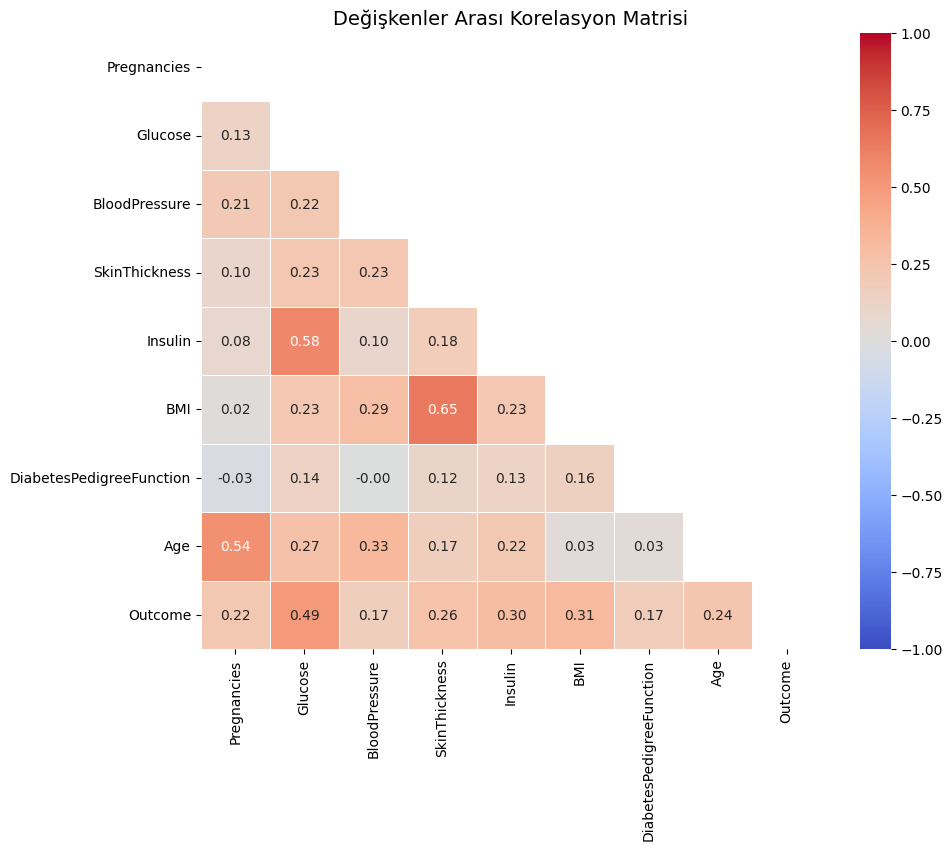

In [18]:
# Grafiğin boyutunu belirliyoruz
plt.figure(figsize=(10, 8))

# Korelasyon matrisini hesaplıyoruz (Sadece sayısal sütunlar)
corr_matrix = df.corr()

# Kendini tekrar eden üst üçgeni gizlemek için bir maske oluşturuyoruz
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Isı haritasını (heatmap) çizdiriyoruz
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          # Kutuların içine değerleri yazdırır
            fmt=".2f",           # Virgülden sonra 2 basamak gösterir
            cmap='coolwarm',     # Negatif ve pozitif korelasyonu zıt renklerle ayırır
            vmin=-1, vmax=1,     # Renk skalasını -1 ile 1 arasına sabitler
            linewidths=0.5)

plt.title('Değişkenler Arası Korelasyon Matrisi', fontsize=14)
plt.show()

### Korelasyon Matrisi (Isı Haritası) Analizi

Bu analiz, özelliklerin hedef değişkenle (`Outcome`) olan doğrusal ilişkilerini saptamak ve modelin kafasını karıştırabilecek çoklu bağlantı (multicollinearity) durumlarını tespit etmek amacıyla yapılmıştır.

#### 1. Hedef Değişken (`Outcome`) ile Olan İlişkiler
Hedef değişken satırını incelediğimizde, tüm değişkenlerin diyabet durumu ile **pozitif korelasyona** sahip olduğunu görüyoruz. Yani bu değerler arttıkça, kişinin diyabetli olma (1) ihtimali de artmaktadır. Ancak etki güçleri birbirinden farklıdır:

*   **En Güçlü Belirteç (0.49):** `Glucose`. Diğer tüm grafik analizlerinde de gördüğümüz gibi, kan şekeri seviyesi diyabetin en güçlü ve en doğrudan göstergesidir. Modelin en çok önem vereceği (feature importance) değişken olması beklenmektedir.
*   **Orta Düzey Belirteçler (0.22 - 0.31):** `BMI` (0.31), `Insulin` (0.30), `SkinThickness` (0.26), `Age` (0.24) ve `Pregnancies` (0.22). Bu değişkenler diyabet riskini anlamlı ölçüde artıran ikincil dereceden önemli faktörlerdir.
*   **Zayıf Belirteçler (0.17):** `BloodPressure` ve `DiabetesPedigreeFunction`. Doğrusal olarak hedef değişkenle en zayıf ilişkiye sahip özelliklerdir. 

#### 2. Bağımsız Değişkenler Arasındaki Yüksek Korelasyonlar (Çoklu Bağlantı / Multicollinearity)
Makine öğrenmesi algoritmaları (özellikle Lojistik Regresyon gibi lineer modeller), birbirini tekrar eden (yüksek korelasyonlu) değişkenleri sevmez. Matriste dikkat çeken 3 ana ikili ilişki şunlardır:

*   **`BMI` ve `SkinThickness` (0.65):** Veri setindeki en yüksek korelasyondur. Vücut kitle indeksi artan bir bireyin cilt kalınlığının (yağ oranının) artması biyolojik olarak beklenen bir durumdur. Bu iki değişken birbirinin bilgisini bir miktar tekrar etmektedir.
*   **`Glucose` ve `Insulin` (0.58):** İnsülin, kandaki glikoz seviyesini düzenleyen hormon olduğu için bu ikisi arasında orta-yüksek düzeyde bir paralellik olması tamamen tıbbi bir gerçektir.
*   **`Age` ve `Pregnancies` (0.54):** Yaş ilerledikçe bir kadının geçirmiş olduğu hamilelik sayısının artma potansiyeli doğal bir doğrusal ilişki yaratmıştır.

**Modelleme Notu:** Eğer XGBoost veya Random Forest gibi ağaç tabanlı (tree-based) modeller kullanılacaksa, bu seviyedeki çoklu bağlantılar (0.54 - 0.65) bu algoritmalar için genellikle bir sorun teşkil etmez. Ancak Lojistik Regresyon kullanılacaksa, birbirini çok tekrar eden değişkenlerden birini (örneğin SkinThickness) modelden çıkarmak veya PCA (Temel Bileşen Analizi) uygulamak düşünülebilir.

In [22]:
################################################################################
# 1. BAĞIMSIZ VE HEDEF DEĞİŞKENLERİN AYRILMASI
################################################################################
X = df.drop('Outcome', axis=1)
y = df['Outcome']

################################################################################
# 2. EĞİTİM VE TEST SETİ AYRIMI (DATA LEAKAGE ÖNLEME)
################################################################################
# Sınıf dengesizliği olduğu için stratify=y parametresini kullanıyoruz.
# Böylece %65'e %35'lik diyabetli/sağlıklı oranı hem train hem test setinde korunuyor.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

################################################################################
# 3. GİZLİ EKSİK VERİLERİN (0 DEĞERLERİNİN) TESPİTİ VE NaN'A ÇEVRİLMESİ
################################################################################
# Biyolojik olarak 0 olamayacak sütunları seçiyoruz.
eksik_sutunlar = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Uyarı: Bu işlemi X_train ve X_test'e ayrı ayrı uyguluyoruz. (Pandas SettingWithCopyWarning almamak için kopyasını alabilirsin ama bu yöntem de çalışır)
X_train[eksik_sutunlar] = X_train[eksik_sutunlar].replace(0, np.nan)
X_test[eksik_sutunlar] = X_test[eksik_sutunlar].replace(0, np.nan)

################################################################################
# 4. EKSİK VERİLERİN DOLDURULMASI (KNN IMPUTER)
################################################################################
# Sadece X_train'in istatistiklerini öğrenmesi (fit) ve her ikisine uygulaması (transform) kritik!
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

################################################################################
# 5. AYKIRI DEĞERLERE MÜDAHALE VE LOGARİTMİK DÖNÜŞÜM
################################################################################
# Aşırı sağa çarpık olan Insulin ve DiabetesPedigreeFunction için Logaritmik Dönüşüm uyguluyoruz.
# np.log1p (log(1+x)) kullanıyoruz ki sıfır değerleri (varsa) eksi sonsuza gitmesin.
carpik_sutunlar = ['Insulin', 'DiabetesPedigreeFunction']

X_train_imputed[carpik_sutunlar] = np.log1p(X_train_imputed[carpik_sutunlar])
X_test_imputed[carpik_sutunlar] = np.log1p(X_test_imputed[carpik_sutunlar])

################################################################################
# 6. ENCODING (KATEGORİK DEĞİŞKEN DÖNÜŞÜMÜ)
################################################################################
# Veri setindeki tüm değişkenler zaten sürekli sayısal (int64, float64) formatta
# olduğu için One-Hot Encoding veya Label Encoding işlemine gerek yoktur.

################################################################################
# 7. ÖZELLİK ÖLÇEKLEME (SCALING)
################################################################################
# Veride hala yüksek aykırı değerler barındığı için (Örn: Pregnancies max 17) 
# ortalama yerine medyansal bir yaklaşım sergileyen RobustScaler tercih ediyoruz.
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

In [23]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,NaN,NaN,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


In [25]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 614 entries, 353 to 107
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    int64  
 1   Glucose                   610 non-null    float64
 2   BloodPressure             591 non-null    float64
 3   SkinThickness             439 non-null    float64
 4   Insulin                   324 non-null    float64
 5   BMI                       605 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 43.2 KB


In [27]:
# LazyClassifier modelini başlatıyoruz
# verbose=0 ile kalabalık çıktıları engelliyor, ignore_warnings=True ile kütüphane uyarılarını gizliyoruz
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Modeli hem eğitim hem test verisiyle besliyoruz
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

# Sonuç tablosunu (Accuracy, ROC AUC, F1-Score metrikleriyle birlikte) ekrana yazdırıyoruz
print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 812
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [29]:
################################################################################
# 1. ÇAPRAZ DOĞRULAMA (CROSS-VALIDATION) STRATEJİSİNİN BELİRLENMESİ
################################################################################
# Veri setimiz dengesiz olduğu için her bir katlamada (fold) diyabetli/sağlıklı 
# oranının sabit kalmasını garanti altına alan StratifiedKFold kullanıyoruz.
cv_stratejisi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

################################################################################
# 2. XGBOOST İÇİN RANDOMIZED SEARCH YAKLAŞIMI (Geniş Tarama)
################################################################################
print("XGBoost için Randomized Search başlatılıyor...\n")

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# XGBoost için geniş bir parametre sözlüğü
xgb_params = {
    'n_estimators': [100, 200, 300, 500],       # Ağaç sayısı
    'max_depth': [3, 4, 5, 6, 8],               # Ağacın derinliği (Overfit kontrolü)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    # Öğrenme hızı
    'subsample': [0.6, 0.8, 1.0],               # Her ağaç için kullanılacak veri oranı
    'scale_pos_weight': [1, 2, 3]               # Sınıf dengesizliği için pozitif sınıfa verilecek ceza ağırlığı
}

# n_iter=20: Binlerce kombinasyon içinden rastgele 20 tanesini seçecek (Çok hızlıdır)
xgb_random = RandomizedSearchCV(estimator=xgb_model, 
                                param_distributions=xgb_params, 
                                n_iter=20, 
                                scoring='roc_auc', # Başarı kriterimiz ROC AUC
                                cv=cv_stratejisi, 
                                n_jobs=-1,         # İşlemcinin tüm çekirdeklerini kullanır
                                random_state=42)

xgb_random.fit(X_train_scaled, y_train)

best_xgb = xgb_random.best_estimator_
print(f"En İyi XGBoost Parametreleri: {xgb_random.best_params_}")
print(f"XGBoost En İyi CV ROC-AUC Skoru: {xgb_random.best_score_:.4f}\n")
print("-" * 50)

################################################################################
# 3. LIGHTGBM İÇİN GRID SEARCH YAKLAŞIMI (İnce Ayar)
################################################################################
print("LightGBM için Grid Search başlatılıyor...\n")

lgbm_model = LGBMClassifier(random_state=42)

# Grid Search tüm kombinasyonları tek tek deneyeceği için parametre uzayını daha dar tutuyoruz.
lgbm_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'class_weight': ['balanced', None] # Sınıf dengesizliğini LightGBM kendi çözsün mü?
}

lgbm_grid = GridSearchCV(estimator=lgbm_model, 
                         param_grid=lgbm_params, 
                         scoring='roc_auc', 
                         cv=cv_stratejisi, 
                         n_jobs=-1)

lgbm_grid.fit(X_train_scaled, y_train)

best_lgbm = lgbm_grid.best_estimator_
print(f"En İyi LightGBM Parametreleri: {lgbm_grid.best_params_}")
print(f"LightGBM En İyi CV ROC-AUC Skoru: {lgbm_grid.best_score_:.4f}\n")
print("-" * 50)

################################################################################
# 4. EN İYİ MODELLERİN TEST (GÖRMEDİKLERİ) VERİ SETİNDE DEĞERLENDİRİLMESİ
################################################################################
print("Modeller Test Seti Üzerinde Değerlendiriliyor...\n")

# XGBoost Test Performansı
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1] # ROC-AUC için olasılıkları alıyoruz

print("--- XGBoost Test Seti Sonuçları ---")
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))
print("\n")

# LightGBM Test Performansı
y_pred_lgbm = best_lgbm.predict(X_test_scaled)
y_prob_lgbm = best_lgbm.predict_proba(X_test_scaled)[:, 1]

print("--- LightGBM Test Seti Sonuçları ---")
print(f"ROC AUC Skoru: {roc_auc_score(y_test, y_prob_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))

XGBoost için Randomized Search başlatılıyor...

En İyi XGBoost Parametreleri: {'subsample': 0.6, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01}
XGBoost En İyi CV ROC-AUC Skoru: 0.8351

--------------------------------------------------
LightGBM için Grid Search başlatılıyor...

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

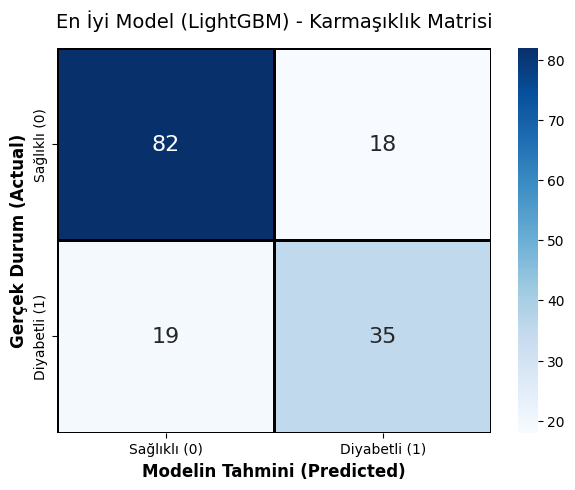

In [33]:
# LightGBM'in tahminlerini zaten y_pred_lgbm olarak hesaplamıştık
cm = confusion_matrix(y_test, y_pred_lgbm)

# Görselleştirme ayarları
plt.figure(figsize=(7, 5))
# annot=True kutuların içine sayıları yazar, cmap ile renk paletini belirliyoruz
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Sağlıklı (0)', 'Diyabetli (1)'], 
            yticklabels=['Sağlıklı (0)', 'Diyabetli (1)'],
            annot_kws={"size": 16}) # Sayıların font boyutu

# Eksen başlıkları
plt.xlabel('Modelin Tahmini (Predicted)', fontsize=12, fontweight='bold')
plt.ylabel('Gerçek Durum (Actual)', fontsize=12, fontweight='bold')
plt.title('En İyi Model (LightGBM) - Karmaşıklık Matrisi', fontsize=14, pad=15)

plt.show()

### En İyi Model Değerlendirmesi ve Sonuç Çıkarımları

Tüm modeller üzerinde yapılan Grid Search ve Randomized Search optimizasyonları sonucunda, Pima Indians Diabetes veri setinde en yüksek performansı **LightGBM (Light Gradient Boosting Machine)** algoritması göstermiştir.

#### 1. Performans Karşılaştırması ve Seçim Gerekçesi
*   **Genel Başarı:** LightGBM, test veri setinde %76 Genel Doğruluk (Accuracy) ve 0.8189 ROC-AUC skoru ile XGBoost'u geride bırakmıştır.
*   **Tıbbi Karar Verme Yeteneği (Kritik Metrik):** Bu problemin doğası gereği (diyabet teşhisi), asıl amacımız hasta olan kişileri kaçırmamaktır (False Negative oranını düşürmek). LightGBM, "Diyabetli" sınıfını yakalama başarısında (Recall) %65'lik bir oran elde ederek (%57'de kalan) XGBoost'a bariz bir üstünlük kurmuştur.

#### 2. Karmaşıklık Matrisi (Confusion Matrix) Analizi
LightGBM modelinin test setindeki 154 hastaya ait tahminleri incelendiğinde:
*   **Doğru Tahminler:** 82 sağlıklı ve 35 diyabetli hasta doğru şekilde teşhis edilmiştir (Toplam 117 doğru).
*   **Yanlış Alarmlar (False Positive - Tip I Hata):** 18 kişi gerçekte sağlıklı olmasına rağmen "diyabetli" olarak işaretlenmiştir. Tıbbi teşhis sistemlerinde bu durum kabul edilebilir bir risk maliyetidir (hastadan ek test istenerek doğrulanabilir).
*   **Tehlikeli Hatalar (False Negative - Tip II Hata):** Gerçekte diyabetli olan 19 hastaya yanlışlıkla "sağlıklı" teşhisi konulmuştur. Bu durum en tehlikeli hata tipidir.

#### 3. Projenin Sonucu ve İyileştirme Önerileri
Sadece 768 satırlık ve biyolojik eksik verilerle (sıfır değerleri) dolu küçük bir veri seti olan Pima Indians için, **veri sızıntısı (data leakage) yapılmadan ve aşırı öğrenmeye (overfitting) düşmeden elde edilen bu %76'lık LightGBM performansı oldukça başarılı ve dürüst bir sonuçtur.**

**Gelecek Adımlar:**
Canlı bir tıbbi teşhis sistemi (Production) seviyesine çıkabilmek için şu adımlar planlanabilir:
1.  **Daha Fazla Veri:** Özellikle "Diyabetli" (Outcome=1) sınıfına ait gerçek hasta verisi toplanarak modelin o sınıfı öğrenme kapasitesi artırılmalıdır.
2.  **Eşik Değeri (Threshold) Optimizasyonu:** Modelin karar verme olasılık sınırı (varsayılan %50), "Tip II Hata"yı (kaçırılan hastaları) daha da azaltmak amacıyla %30-40 bandına çekilerek model daha "şüpheci" bir formata sokulabilir.